# Loan Default Prediction using PyTorch

## Objective

Build a Multi-Layer Perceptron (MLP) using PyTorch for Loan Default Prediction by converting the cleaned dataset into tensors and training the model using a manual training loop.

# Import Libraries

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [2]:
torch.manual_seed(42)

# Set Random Seed

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Random Seed Set Successfully!")

Random Seed Set Successfully!


# Load Dataset

In [4]:
df = pd.read_csv("train_ctrUa4K.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data Cleaning

In [5]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df.drop("Loan_ID", axis=1, inplace=True)

# Encode Categorical Features

In [6]:
encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Split Dataset

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance Training Data using SMOTE

In [8]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(y_train.shape)

(674, 11)
(674,)


# Convert Data into PyTorch Tensors

In [9]:
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

print(X_train.shape)
print(y_train.shape)

torch.Size([674, 11])
torch.Size([674])


C:\Users\HEC\AppData\Local\Temp\ipykernel_11268\3431909480.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.LongTensor(y_train.values)


# Build Multi-Layer Perceptron (MLP)

In [24]:
class LoanMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        return self.network(x)


baseline_model = LoanMLP()

regularized_model = RegularizedMLP()

print("Baseline Model")
print(baseline_model)

print()

print("Regularized Model")
print(regularized_model)

Baseline Model
LoanMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)

Regularized Model
RegularizedMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=8, out_features=2, bias=True)
  )
)


# Regularized Neural Network

In [23]:
class RegularizedMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(X_train.shape[1], 16),

            nn.BatchNorm1d(16),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(16, 8),

            nn.BatchNorm1d(8),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(8, 2)

        )

    def forward(self, x):
        return self.network(x)

# Create TensorDataset and DataLoader

In [11]:
from torch.utils.data import TensorDataset, DataLoader


In [12]:
train_dataset = TensorDataset(X_train, y_train)

val_dataset = TensorDataset(X_test, y_test)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [14]:
print("Training batches:", len(train_loader))

print("Validation batches:", len(val_loader))

Training batches: 11
Validation batches: 2


# Define Loss Function and Optimizer

In [25]:
criterion = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

regularized_optimizer = optim.Adam(regularized_model.parameters(), lr=0.001)

# Train the Model using Mini-Batches

In [27]:
epochs = 30

# Train Both Models

In [28]:
baseline_train_losses = []
baseline_val_losses = []

regularized_train_losses = []
regularized_val_losses = []


for epoch in range(30):

    # -------------------------------
    # Baseline Model Training
    # -------------------------------

    baseline_model.train()

    running_train_loss = 0.0

    for inputs, labels in train_loader:

        baseline_optimizer.zero_grad()

        outputs = baseline_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        baseline_optimizer.step()

        running_train_loss += loss.item()

    average_train_loss = running_train_loss / len(train_loader)

    baseline_train_losses.append(average_train_loss)


    # Validation

    baseline_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = baseline_model(inputs)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    average_val_loss = running_val_loss / len(val_loader)

    baseline_val_losses.append(average_val_loss)


    # -------------------------------
    # Regularized Model Training
    # -------------------------------

    regularized_model.train()

    running_train_loss = 0.0

    for inputs, labels in train_loader:

        regularized_optimizer.zero_grad()

        outputs = regularized_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        regularized_optimizer.step()

        running_train_loss += loss.item()

    average_train_loss = running_train_loss / len(train_loader)

    regularized_train_losses.append(average_train_loss)


    # Validation

    regularized_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = regularized_model(inputs)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    average_val_loss = running_val_loss / len(val_loader)

    regularized_val_losses.append(average_val_loss)


    print(
        f"Epoch {epoch+1}/30 | "
        f"Baseline Train: {baseline_train_losses[-1]:.4f} | "
        f"Baseline Val: {baseline_val_losses[-1]:.4f} | "
        f"Regularized Train: {regularized_train_losses[-1]:.4f} | "
        f"Regularized Val: {regularized_val_losses[-1]:.4f}"
    )

Epoch 1/30 | Baseline Train: 0.9573 | Baseline Val: 1.1321 | Regularized Train: 0.6899 | Regularized Val: 0.6767
Epoch 2/30 | Baseline Train: 0.9710 | Baseline Val: 1.0111 | Regularized Train: 0.6971 | Regularized Val: 0.6763
Epoch 3/30 | Baseline Train: 1.0890 | Baseline Val: 1.6823 | Regularized Train: 0.6946 | Regularized Val: 0.6777
Epoch 4/30 | Baseline Train: 1.3916 | Baseline Val: 1.0201 | Regularized Train: 0.7003 | Regularized Val: 0.6816
Epoch 5/30 | Baseline Train: 1.2588 | Baseline Val: 2.5977 | Regularized Train: 0.6933 | Regularized Val: 0.6785
Epoch 6/30 | Baseline Train: 1.3169 | Baseline Val: 1.1713 | Regularized Train: 0.6941 | Regularized Val: 0.6793
Epoch 7/30 | Baseline Train: 0.9670 | Baseline Val: 1.9399 | Regularized Train: 0.6982 | Regularized Val: 0.6769
Epoch 8/30 | Baseline Train: 1.0118 | Baseline Val: 2.5336 | Regularized Train: 0.6921 | Regularized Val: 0.6771
Epoch 9/30 | Baseline Train: 1.3931 | Baseline Val: 1.0073 | Regularized Train: 0.6986 | Regular

# Baseline vs Regularized Model Comparison

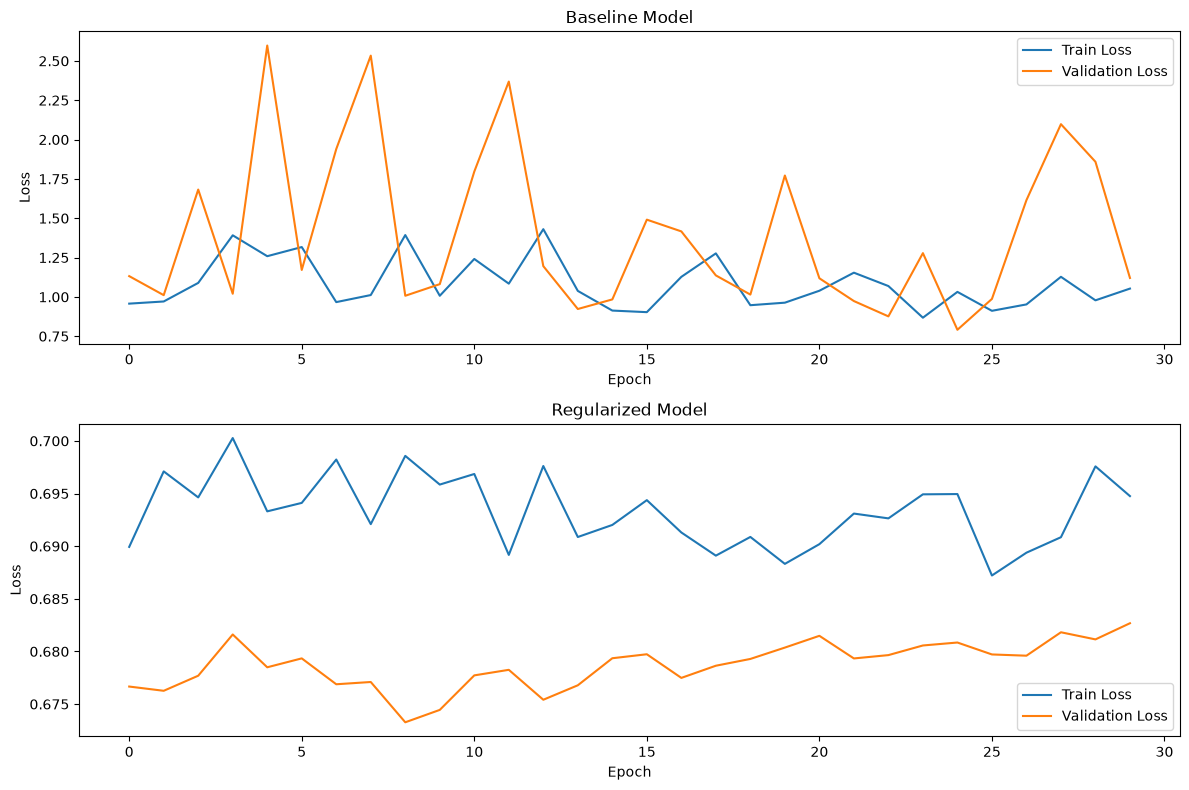

In [29]:
plt.figure(figsize=(12, 8))

# Baseline
plt.subplot(2, 1, 1)
plt.plot(baseline_train_losses, label="Train Loss")
plt.plot(baseline_val_losses, label="Validation Loss")
plt.title("Baseline Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Regularized
plt.subplot(2, 1, 2)
plt.plot(regularized_train_losses, label="Train Loss")
plt.plot(regularized_val_losses, label="Validation Loss")
plt.title("Regularized Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Explanation

## Batch Normalization

Batch Normalization normalizes the output of a layer using the mean and standard deviation of each mini-batch. This helps stabilize the learning process, allows faster convergence, and reduces internal covariate shift.

Batch Normalization also learns two parameters:

- γ (Gamma): Controls the scale of the normalized output.
- β (Beta): Controls the shift of the normalized output.

These learnable parameters allow the network to adjust the normalized values during training.

---

## Dropout

Dropout is a regularization technique that randomly deactivates a fraction of neurons during training. In this project, a dropout rate of 0.3 means that approximately 30% of neurons are randomly ignored during each training step.

This forces the network to learn more robust features and helps reduce overfitting.

### Inverted Dropout Scaling

PyTorch uses inverted dropout. During training, the remaining active neurons are automatically scaled by `1 / (1 - p)` so that the expected activation remains the same.

During evaluation (`model.eval()`), dropout is automatically disabled and all neurons are used.

# Model Evaluation

In [19]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in val_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 65.04%


# Conclusion

The PyTorch MLP model was successfully upgraded using TensorDataset and DataLoader for mini-batch training. The Adam optimizer improved the optimization process, while validation loss tracking helped monitor the model's performance throughout training. The comparison of training and validation loss provides insight into the model's learning behavior and potential overfitting.